# Cross-Domain Celebrity Retrieval — CLIP and ArcFace Fine Tuning


In [1]:
# in order to import functions

import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import torch
import clip
from torch.utils.data import DataLoader
print('All imports OK')

# the remaining needed libraries are imported using src files, to avoid clutter

All imports OK


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla V100-PCIE-16GB
VRAM   : 16.9 GB


### Data & saving checkpoints

In [3]:
# windows syntax:
# comp_train_dir="..\\data\\competition\\train\\train"
# comp_test_dir="..\\data\\competition\\test"

# linux syntax:
comp_train_dir="../data/competition/train/train"
comp_test_dir="../data/competition/test"

imgs_dir=comp_train_dir


In [4]:
SAVE_DIR = "./checkpoints/clip_arcface_best"

os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Checkpoints will be saved to: {SAVE_DIR}')

Checkpoints will be saved to: ./checkpoints/clip_arcface_best


## Cell 5 — Load CLIP ViT-L/14

In [5]:
print('Loading CLIP ViT-L/14...')
clip_model, clip_preprocess = clip.load('ViT-L/14')

# Convert to float32 — CLIP loads as float16 on GPU by default
# ArcFace overflows to NaN in float16
clip_model = clip_model.float()
clip_model.eval()

EMBED_DIM = clip_model.visual.output_dim
# print(f'CLIP loaded on : {device}')
print(f'Embedding dim  : {EMBED_DIM}')  # 768 for ViT-L/14b

Loading CLIP ViT-L/14...
Embedding dim  : 768


## Build train/val:
Building training and validation sets, with an 80%-20% split

In [6]:
from src.datasets import TrainDataset

train_dataset = TrainDataset(comp_train_dir, clip_preprocess, min_images=2)
NUM_CLASSES   = train_dataset.num_classes

n_train = int(0.8 * len(train_dataset))
n_val   = len(train_dataset) - n_train
train_ds, val_ds = torch.utils.data.random_split(
    train_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

is_cuda = (device.type == 'cuda')
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,
                          num_workers=2, pin_memory=is_cuda)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=is_cuda)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

Train dataset: 250 identities, 5000 images
Train batches : 500
Val   batches : 63


## ArcFace head


In [7]:
from src.arcface_head import ArcFaceHead

arcface_head = ArcFaceHead(
    embedding_dim=EMBED_DIM,
    num_classes=NUM_CLASSES,
    s=30.0,
    m=0.4
).to(device)

print(f'ArcFace head: {EMBED_DIM} → {NUM_CLASSES} classes')
print(f'Trainable params: {sum(p.numel() for p in arcface_head.parameters()):,}')

ArcFace head: 768 → 250 classes
Trainable params: 192,000


## Fine-tuning
Setting up:

In [8]:
# Freeze all CLIP params
for param in clip_model.parameters():
    param.requires_grad = False

# Unfreeze last 6 transformer blocks + final LayerNorm + projection
for block in list(clip_model.visual.transformer.resblocks)[-6:]:
    for param in block.parameters():
        param.requires_grad = True
for param in clip_model.visual.ln_post.parameters():
    param.requires_grad = True
if hasattr(clip_model.visual, 'proj') and clip_model.visual.proj is not None:
    clip_model.visual.proj.requires_grad = True

trainable = sum(p.numel() for p in clip_model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in clip_model.parameters())
print(f'Trainable: {trainable:,} / {total_p:,} ({100*trainable/total_p:.1f}%)')

optimizer = torch.optim.AdamW([
    {'params': filter(lambda p: p.requires_grad, clip_model.parameters()), 'lr': 5e-6},
    {'params': arcface_head.parameters(), 'lr': 1e-4}
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)





Trainable: 76,365,824 / 427,616,513 (17.9%)


Actual finetuning:

In [9]:
torch.cuda.empty_cache()

In [10]:
from src.train import train_one_epoch
from src.retrieval import evaluate_retrieval

EPOCHS    = 10
best_top1 = 0.0

history = {
    'loss': [],
    'top1': [],
    'top10': []
}

print('Starting fine-tuning...\n')
for epoch in range(1, EPOCHS + 1):
    avg_loss = train_one_epoch(clip_model, arcface_head, train_loader, optimizer, device, epoch)
    scheduler.step()
    top1, top10 = evaluate_retrieval(clip_model, val_loader, device)
    print(f'Epoch {epoch}/{EPOCHS} | Loss: {avg_loss:.4f} | Top-1: {top1*100:.2f}% | Top-10: {top10*100:.2f}%')

    # save metrics for plotting later
    history['loss'].append(avg_loss)
    history['top1'].append(top1)
    history['top10'].append(top10)

    if top1 > best_top1:
        best_top1 = top1
        torch.save({
            'epoch'      : epoch,
            'clip_state' : clip_model.state_dict(),
            'head_state' : arcface_head.state_dict(),
            'top1'       : top1
        }, f'{SAVE_DIR}/best_model.pth')
        print(f'   New best saved (Top-1={top1*100:.2f}%)')

print(f'\nTraining complete. Best Top-1: {best_top1*100:.2f}%')

Starting fine-tuning...

  Epoch 1 | Batch 20/500 | Loss: 17.3924
  Epoch 1 | Batch 40/500 | Loss: 17.4510
  Epoch 1 | Batch 60/500 | Loss: 17.5687
  Epoch 1 | Batch 80/500 | Loss: 17.5820
  Epoch 1 | Batch 100/500 | Loss: 16.6975
  Epoch 1 | Batch 120/500 | Loss: 17.4438
  Epoch 1 | Batch 140/500 | Loss: 16.7677
  Epoch 1 | Batch 160/500 | Loss: 16.7924


/home/disi/miniconda3/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Epoch 1 | Batch 180/500 | Loss: 17.0431
  Epoch 1 | Batch 200/500 | Loss: 17.0254
  Epoch 1 | Batch 220/500 | Loss: 16.1857
  Epoch 1 | Batch 240/500 | Loss: 15.9831
  Epoch 1 | Batch 260/500 | Loss: 16.8941
  Epoch 1 | Batch 280/500 | Loss: 16.1913
  Epoch 1 | Batch 300/500 | Loss: 14.7278
  Epoch 1 | Batch 320/500 | Loss: 16.4267
  Epoch 1 | Batch 340/500 | Loss: 15.5313
  Epoch 1 | Batch 360/500 | Loss: 14.0923
  Epoch 1 | Batch 380/500 | Loss: 16.4057
  Epoch 1 | Batch 400/500 | Loss: 15.3815
  Epoch 1 | Batch 420/500 | Loss: 14.0322
  Epoch 1 | Batch 440/500 | Loss: 13.8551
  Epoch 1 | Batch 460/500 | Loss: 13.9236
  Epoch 1 | Batch 480/500 | Loss: 14.8838
  Epoch 1 | Batch 500/500 | Loss: 14.1199


/home/disi/miniconda3/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/10 | Loss: 16.1291 | Top-1: 61.20% | Top-10: 76.90%
   New best saved (Top-1=61.20%)
  Epoch 2 | Batch 20/500 | Loss: 12.3192
  Epoch 2 | Batch 40/500 | Loss: 13.4133
  Epoch 2 | Batch 60/500 | Loss: 12.6432
  Epoch 2 | Batch 80/500 | Loss: 11.0195


...

Epoch 9/10 | Loss: 0.2026 | Top-1: 65.70% | Top-10: 79.00%
  Epoch 10 | Batch 20/500 | Loss: 0.0491
  Epoch 10 | Batch 40/500 | Loss: 0.0150
  Epoch 10 | Batch 60/500 | Loss: 0.0092


/home/disi/miniconda3/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Epoch 10 | Batch 80/500 | Loss: 0.1618
  Epoch 10 | Batch 100/500 | Loss: 0.0099
  Epoch 10 | Batch 120/500 | Loss: 0.2217
  Epoch 10 | Batch 140/500 | Loss: 0.0141
  Epoch 10 | Batch 160/500 | Loss: 0.0158
  Epoch 10 | Batch 180/500 | Loss: 0.0107
  Epoch 10 | Batch 200/500 | Loss: 0.0441
  Epoch 10 | Batch 220/500 | Loss: 0.0150
  Epoch 10 | Batch 240/500 | Loss: 0.1631
  Epoch 10 | Batch 260/500 | Loss: 0.0113
  Epoch 10 | Batch 280/500 | Loss: 0.0623
  Epoch 10 | Batch 300/500 | Loss: 0.1562
  Epoch 10 | Batch 320/500 | Loss: 0.0396
  Epoch 10 | Batch 340/500 | Loss: 0.0848
  Epoch 10 | Batch 360/500 | Loss: 0.0123
  Epoch 10 | Batch 380/500 | Loss: 0.0107
  Epoch 10 | Batch 400/500 | Loss: 0.0097
  Epoch 10 | Batch 420/500 | Loss: 0.0761
  Epoch 10 | Batch 440/500 | Loss: 0.0317
  Epoch 10 | Batch 460/500 | Loss: 0.0077
  Epoch 10 | Batch 480/500 | Loss: 0.0226
  Epoch 10 | Batch 500/500 | Loss: 0.1413


/home/disi/miniconda3/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 10/10 | Loss: 0.1191 | Top-1: 65.30% | Top-10: 79.00%

Training complete. Best Top-1: 66.10%


Plot finetuning stats

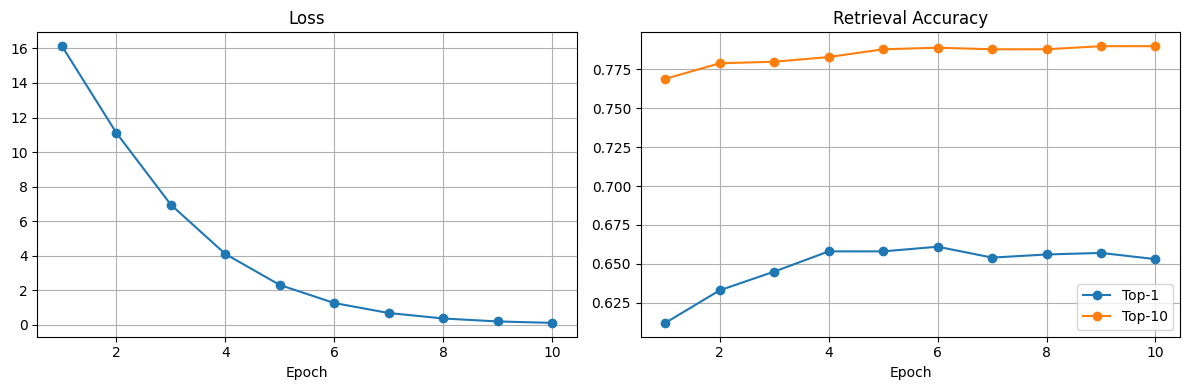

In [26]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))


ax1.plot(epochs, history['loss'], marker='o')
ax1.grid(True)
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')

ax2.plot(epochs, history['top1'], marker='o', label='Top-1')
ax2.plot(epochs, history['top10'], marker='o', label='Top-10')
ax2.grid(True)
ax2.set_title('Retrieval Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()

plt.savefig('training_history.png')
plt.show()

## Load Best Checkpoint

In [12]:
CKPT_PATH = f'{SAVE_DIR}/best_model.pth'
ckpt = torch.load(CKPT_PATH, map_location=device)
clip_model.load_state_dict(ckpt['clip_state'])
clip_model.eval()
print(f'Loaded checkpoint from epoch {ckpt["epoch"]} (Top-1 = {ckpt["top1"]*100:.2f}%)')

Loaded checkpoint from epoch 6 (Top-1 = 66.10%)


## Testing & visualisation

Extracting query embeddings...
Extracting gallery embeddings...


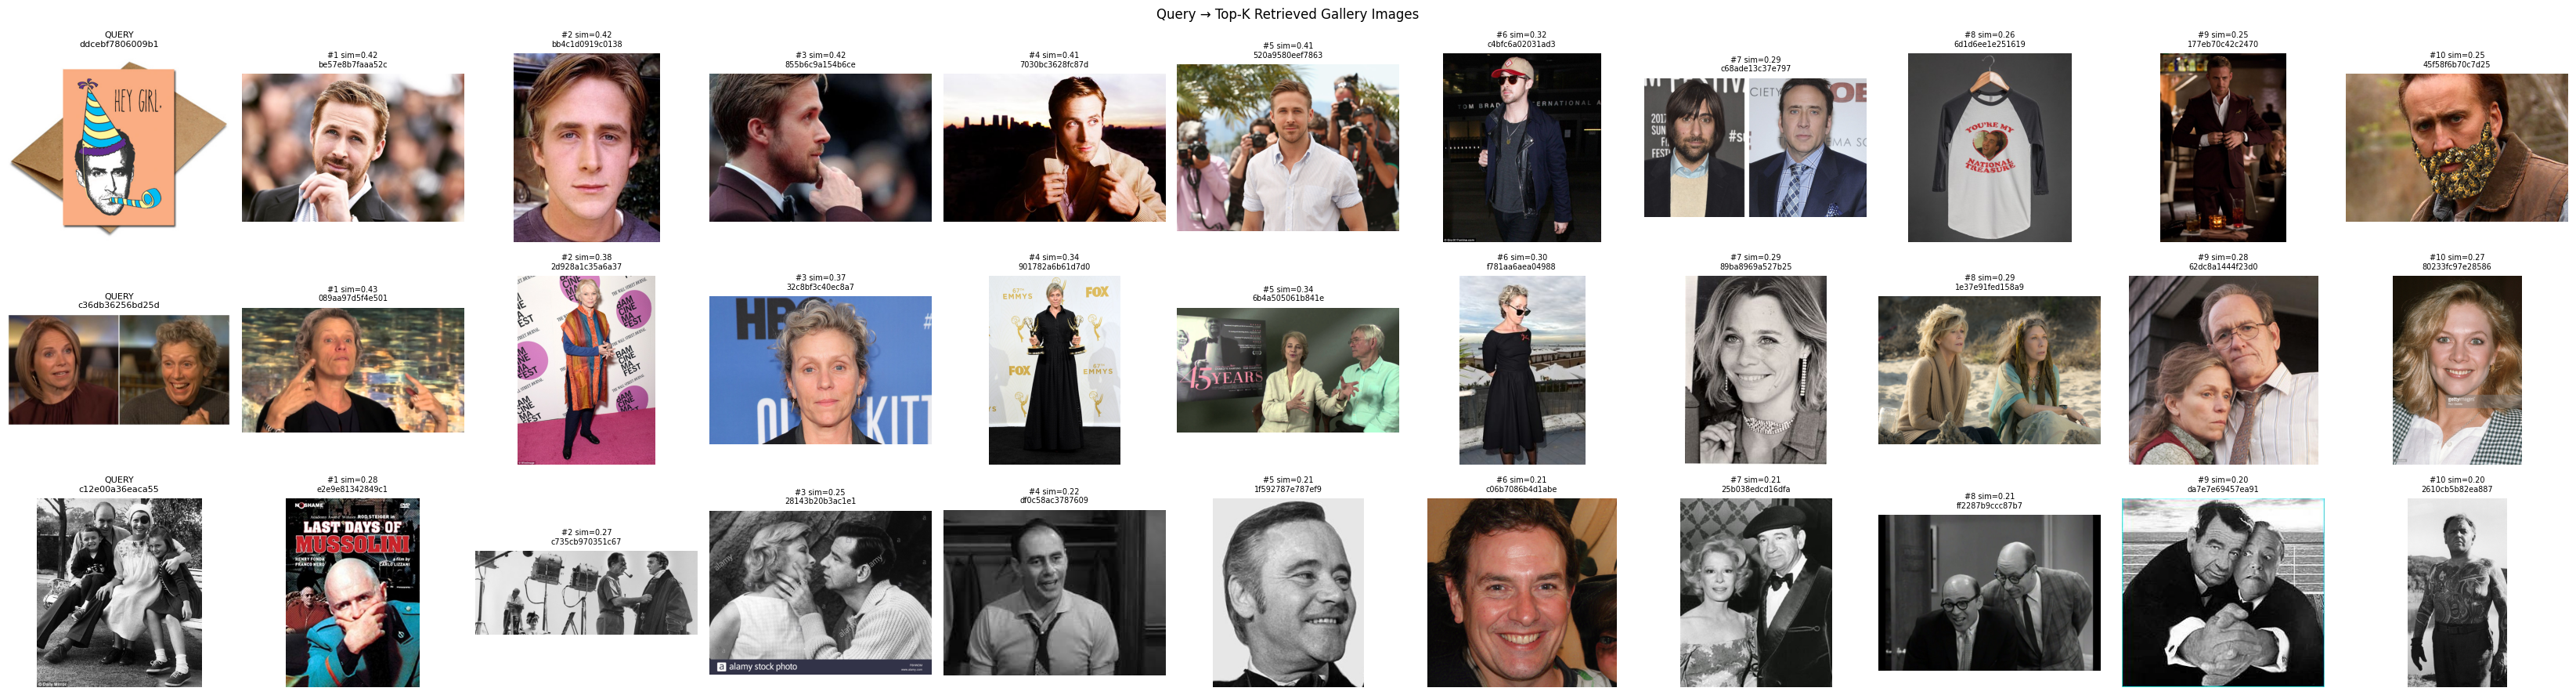

In [13]:
from src.generate_submission import generate_submission
from src.retrieval import visualise_retrieval

# windows syntax
# QUERY_DIR="..\\data\\competition\\test\\query"
# GALLERY_DIR="..\\data\\competition\\test\\gallery"

# linux syntax:
QUERY_DIR="../data/competition/test/query"
GALLERY_DIR="../data/competition/test/gallery"

# BEST MODEL PERFORMANCE
clip_model.eval()
submission = generate_submission(
    QUERY_DIR, GALLERY_DIR,
    model=clip_model, preprocess=clip_preprocess, top_k=10
)

# Visualise 3 random queries
visualise_retrieval(QUERY_DIR, GALLERY_DIR,
                    clip_model, clip_preprocess,
                    num_queries=3, top_k=10)

Visualize where the model was most confidently wrong

## Generate Exam Submission and evaluate accuracy EDIT
The evaluation website does not work anymore: this was the setup for upload and score generation

In [15]:
# import os
# import random
# import matplotlib.pyplot as plt
# import PIL.Image as PILImage

# def visualise_test_submission(query_dir, gallery_dir, submission_dict, num_queries=3, top_k=5):
#     """
#     Visualises submission dictionary mapping by looking up actual files
#     inside the final query_dir and gallery_dir paths.
#     """
#     # Pick a few sample queries from the submission dictionary keys
#     q_names = list(submission_dict.keys())
#     if not q_names:
#         print("Submission dictionary is empty! Run the generation block first.")
#         return

#     q_sample = random.sample(q_names, min(num_queries, len(q_names)))

#     # Construct plotting grid
#     fig, axes = plt.subplots(len(q_sample), top_k + 1,
#                              figsize=(3 * (top_k + 1), 3 * len(q_sample)))

#     # Handle single row formatting edge case
#     if num_queries == 1 or len(q_sample) == 1:
#         axes = [axes]

#     for row, q_name in enumerate(q_sample):
#         # 1. Render original test Query image
#         q_path = os.path.join(query_dir, q_name)
#         if os.path.exists(q_path):
#             q_img = PILImage.open(q_path).convert('RGB')
#             axes[row][0].imshow(q_img)
#         axes[row][0].set_title(f'QUERY\n{q_name[:15]}', fontsize=8, color='blue')
#         axes[row][0].axis('off')

#         # 2. Render ranked predictions returned by the model
#         retrieved_list = submission_dict[q_name]
#         for col in range(top_k):
#             ax = axes[row][col + 1]
#             if col < len(retrieved_list):
#                 g_name = retrieved_list[col]
#                 g_path = os.path.join(gallery_dir, g_name)

#                 if os.path.exists(g_path):
#                     g_img = PILImage.open(g_path).convert('RGB')
#                     ax.imshow(g_img)
#                 ax.set_title(f'Rank #{col+1}\n{g_name[:15]}', fontsize=7)
#             ax.axis('off')

#     plt.suptitle('Submission Preview: Target Queries → Top Predicted Gallery Matches', fontsize=12, weight='bold')
#     plt.tight_layout()
#     plt.show()

# # Run the preview visualization pass using your live active test folders
# visualise_test_submission(
#     query_dir=QUERY_DIR,
#     gallery_dir=GALLERY_DIR,
#     submission_dict=submission,
#     num_queries=3,
#     top_k=10
# )

In [16]:
# from src.generate_submission import visualise_test_submission

# # Run the preview visualization pass using your live active test folders
# visualise_test_submission(
#     query_dir=QUERY_DIR,
#     gallery_dir=GALLERY_DIR,
#     submission_dict=submission,
#     num_queries=3,
#     top_k=10
# )

In [17]:
# import json
# import requests

In [18]:
# def submit(results, groupname, url):
#     res = {}
#     res['groupname'] = groupname
#     res['images'] = results
#     res = json.dumps(res)
#     # print(res)
#     response = requests.post(url, res)
#     try:
#         result = json.loads(response.text)
#         print(f"accuracy is {result['accuracy']}")
#     except json.JSONDecodeError:
#         print(f"ERROR: {response.text}")


# submit(results=submission,groupname="caggol",url="http://videosim.disi.unitn.it:3001/retrieval/")